In [1]:
import pandas as pd

In [2]:
weather_df = pd.read_csv("tsf_compare/data/weather/jena_climate_2009_2016.csv")
weather_df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
with gzip.open(PATH, "rt") as f:
    df = pd.read_csv(f, header=None)

values = df.values.astype(np.float32)

  0.004800,0.014600,0.028900,0.014200,0.006400,0.023200,0.016200,0.024200,0.034100,0.037500,0.014400,0.009800,0.015700,0.021600,0.034500,0.054500,0.006100,0.027900,0.020000,0.012800,0.018600,0.009700,0.015400,0.026700,0.044100,0.032000,0.019500,0.016900,0.056500,0.033600,0.020000,0.020800,0.034100,0.045700,0.017700,0.023600,0.008200,0.049600,0.044100,0.009700,0.019700,0.000100,0.032100,0.018700,0.018100,0.037000,0.040300,0.010900,0.028100,0.029700,0.027900,0.012700,0.024900,0.017000,0.030800,0.035300,0.014700,0.021900,0.032200,0.024800,0.027500,0.013100,0.006000,0.009700,0.016600,0.024900,0.034000,0.015400,0.015300,0.033300,0.020700,0.017200,0.015600,0.015200,0.010800,0.010400,0.024500,0.029400,0.019300,0.037900,0.015800,0.016600,0.016900,0.008800,0.022600,0.019200,0.025300,0.051900,0.015300,0.009300,0.033000,0.013200,0.012800,0.077600,0.006400,0.032400,0.009900,0.012700,0.017800,0.013200,0.012800,0.014800,0.017000,0.018600,0.024600,0.020100,0.007900,0.014100,0.026400,0.022100,0.009700

In [5]:
import pandas as pd


def _prepare_dataframe(df):
    if "Date Time" not in df.columns:
        raise ValueError("DataFrame must contain a 'Date Time' column.")

    df = df.copy()

    df["Date Time"] = pd.to_datetime(
        df["Date Time"],
        format="%d.%m.%Y %H:%M:%S",
        errors="raise"
    )

    df = df.sort_values("Date Time")
    df.set_index("Date Time", inplace=True)

    return df


def _get_resolution(df):
    """
    Estimate the sampling interval using the median difference.
    Returns a pandas Timedelta.
    """
    diffs = df.index.to_series().diff().dropna()

    if diffs.empty:
        raise ValueError("DataFrame must contain at least two timestamps.")

    return diffs.median()


def group_by_hour(df):
    """
    Group data by hour only if the original frequency is finer than 1 hour.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    if resolution >= pd.Timedelta(hours=1):
        raise ValueError(
            f"Cannot group by hour. Data resolution is {resolution}."
        )

    return df.resample("1h").mean(numeric_only=True)


def group_by_day(df):
    """
    Group data by day only if the original frequency is finer than 1 day.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    if resolution >= pd.Timedelta(days=1):
        raise ValueError(
            f"Cannot group by day. Data resolution is {resolution}."
        )

    return df.resample("1D").mean(numeric_only=True)


def group_by_month(df):
    """
    Group data by month only if the original frequency is finer than 1 month.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    # Approximate month as 28 days (safe lower bound)
    if resolution >= pd.Timedelta(days=28):
        raise ValueError(
            f"Cannot group by month. Data resolution is {resolution}."
        )

    return df.resample("MS").mean(numeric_only=True)

In [6]:
# 15-minute data
hourly = group_by_hour(weather_df)
hourly.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


In [8]:
daily = group_by_day(weather_df)
daily.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,999.145594,-6.810629,266.414545,-8.015594,91.086014,3.691119,3.355524,0.335315,2.091049,3.357832,1305.178252,0.778601,1.378252,181.863077
2009-01-02,999.600625,-3.728194,269.463194,-4.824861,92.086806,4.640069,4.267292,0.373056,2.659792,4.268750,1290.353194,1.419514,2.227361,125.072014
2009-01-03,998.548611,-5.271736,268.002292,-9.015833,76.458056,4.184792,3.107708,1.077014,1.937778,3.111944,1297.117014,1.250903,2.065069,190.383333
2009-01-04,988.510694,-1.375208,272.685347,-2.897014,89.417361,5.524306,4.938958,0.584861,3.114028,4.997014,1264.634514,1.720417,3.564861,213.069861
2009-01-05,990.405694,-4.867153,269.039306,-6.797292,86.260417,4.362708,3.806736,0.555625,2.397014,3.847778,1284.372778,3.800278,5.940000,118.287361


In [7]:
monthly = group_by_month(weather_df)
monthly.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,988.988075,-3.626617,270.409572,-5.887934,84.992651,5.000858,4.196778,0.804076,2.652147,4.256180,1276.954094,1.784855,2.892657,150.870558
2009-02-01,985.634010,0.169950,274.473770,-2.186749,84.723492,6.352691,5.353219,0.999516,3.388271,5.435491,1253.876491,2.045833,3.498914,193.228611
2009-03-01,986.123026,3.989944,278.266989,0.353797,78.468752,8.288454,6.389973,1.898461,4.044017,6.485105,1236.608163,2.429601,4.088239,201.683315
2009-04-01,987.523086,11.889757,286.080206,5.742546,69.176981,14.639894,9.316218,5.323556,5.892667,9.439019,1202.978444,1.853863,3.121630,143.162153
2009-05-01,992.105999,13.433905,287.247596,7.815836,70.967000,16.044648,10.835849,5.208658,6.826414,10.927278,1201.285078,2.080842,3.556891,168.264149


In [13]:
import matplotlib.pyplot as plt

def plotting(x=None, y=None):
    plt.figure(figsize=(16, 6))
    if x is not None and y is not None:
        plt.plot(x, y)
    if x is None and y is not None:
        plt.plot(y)
    plt.grid()
    plt.show()

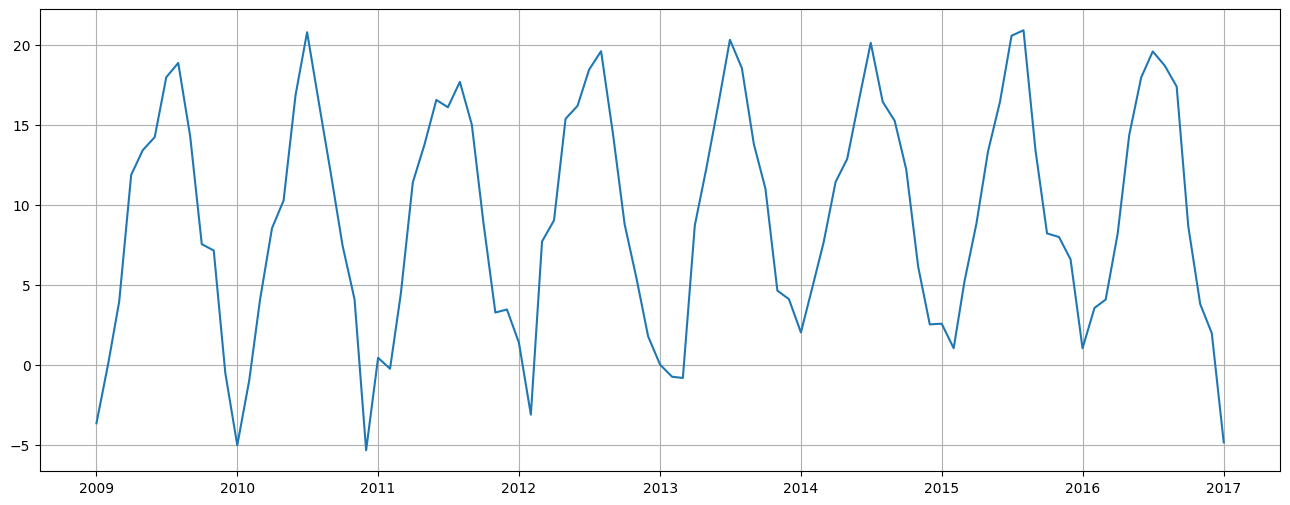

In [17]:
plotting(x=monthly.index, y=monthly["T (degC)"])